<h1 style="font-size: 40px; font-weight: bold">Dengue Data Analysis</h1>
<h2>2016-2020</h2>

<h2>Analyst: Ryom James Alemania</h2>
<h1 style="font-size: 20px; font-weight: bold;">Data Preparation</h1>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from IPython.display import display, HTML
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore")

In [2]:
dengue_f = pd.read_csv("datasets/dengue.csv")

In [3]:
dengue_f

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h1>Data Cleansing</h1>

In [4]:
dengue_f["Month"] = dengue_f["Month"].astype("category")
dengue_f["Year"] = dengue_f["Year"].astype("category")
dengue_f["Region"] = dengue_f["Region"].astype("category")

In [5]:
dengue_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Month          1020 non-null   category
 1   Year           1020 non-null   category
 2   Region         1020 non-null   category
 3   Dengue_Cases   1020 non-null   int64   
 4   Dengue_Deaths  1020 non-null   int64   
dtypes: category(3), int64(2)
memory usage: 20.3 KB


In [6]:
dengue_f['Death_rate']= (dengue_f['Dengue_Deaths']/dengue_f['Dengue_Cases'] * 100)

<h1>Insights</h1>

<h1>1. What was the highest cases per month</h1>

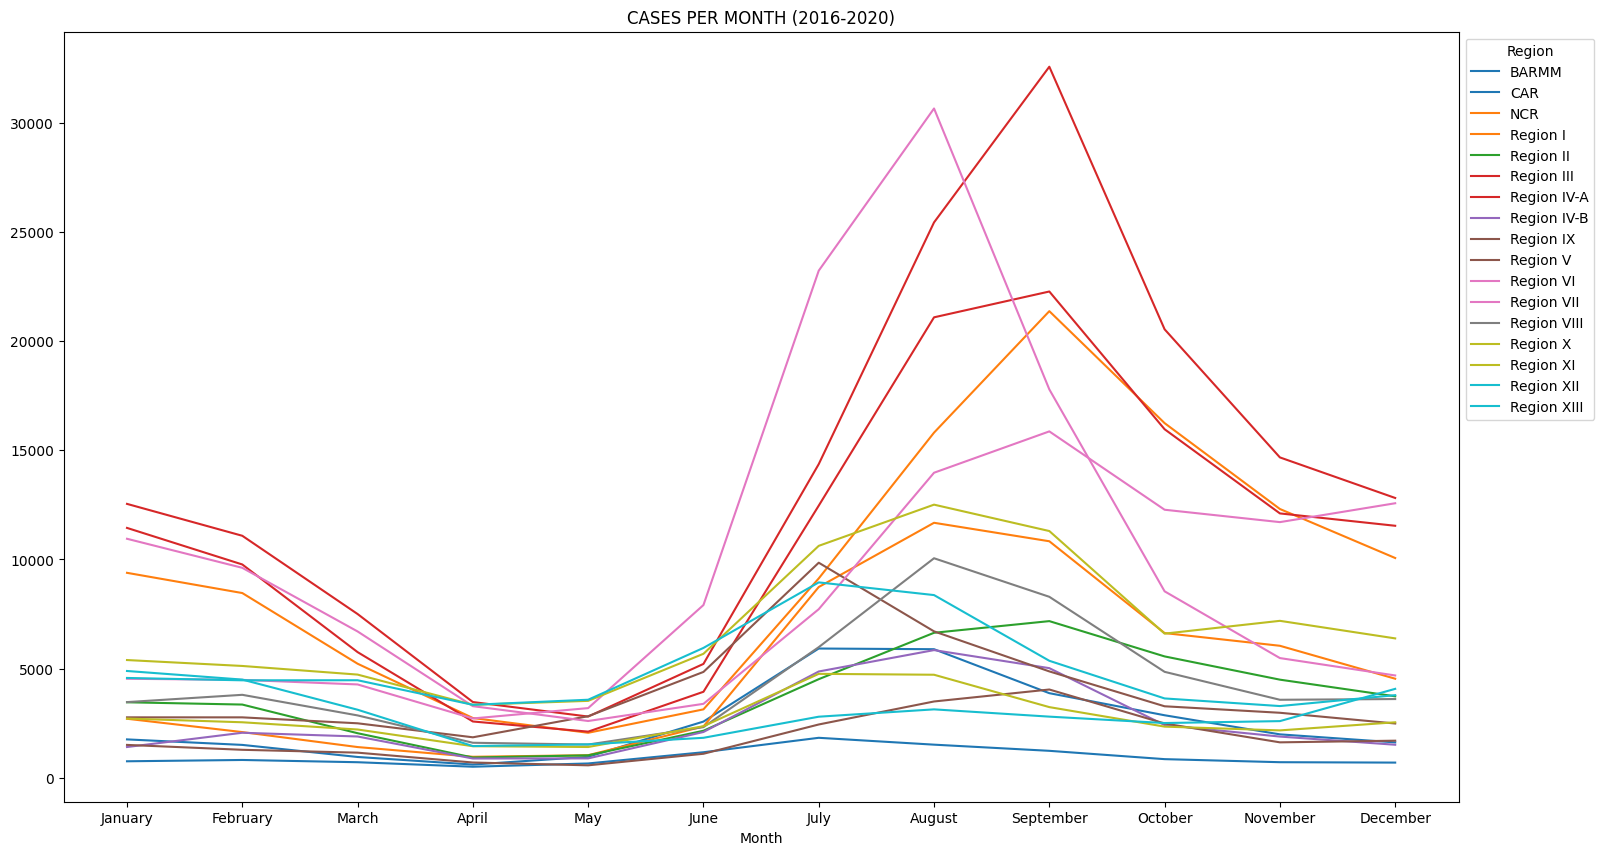

In [7]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
dengue_f["Month"]=pd.Categorical(dengue_f["Month"],categories=month_order,ordered=True)
monthly_cases = dengue_f.groupby(['Month','Region'])["Dengue_Cases"].sum()

monthly_cases_unstacked = monthly_cases.unstack()

regions = monthly_cases_unstacked.columns
colors = plt.cm.get_cmap("tab10", len(regions)) 

monthly_cases_unstacked.plot(kind='line', color=colors(range(len(regions))))

plt.title("CASES PER MONTH (2016-2020)")
plt.gcf().set_size_inches(18,10)
plt.xticks(range(0,12),month_order)
plt.legend(title='Region', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [8]:
month_cases = dengue_f.groupby('Month')['Dengue_Cases'].sum()
highest_month = month_cases.idxmax()

In [9]:
highest_month

'August'

<h2>August has the highest number of cases per month</h2>

<h1>2. What year has the highest cases?</h1>

(array([2015.5, 2016. , 2016.5, 2017. , 2017.5, 2018. , 2018.5, 2019. ,
        2019.5, 2020. , 2020.5]),
 [Text(2015.5, 0, '2015.5'),
  Text(2016.0, 0, '2016.0'),
  Text(2016.5, 0, '2016.5'),
  Text(2017.0, 0, '2017.0'),
  Text(2017.5, 0, '2017.5'),
  Text(2018.0, 0, '2018.0'),
  Text(2018.5, 0, '2018.5'),
  Text(2019.0, 0, '2019.0'),
  Text(2019.5, 0, '2019.5'),
  Text(2020.0, 0, '2020.0'),
  Text(2020.5, 0, '2020.5')])

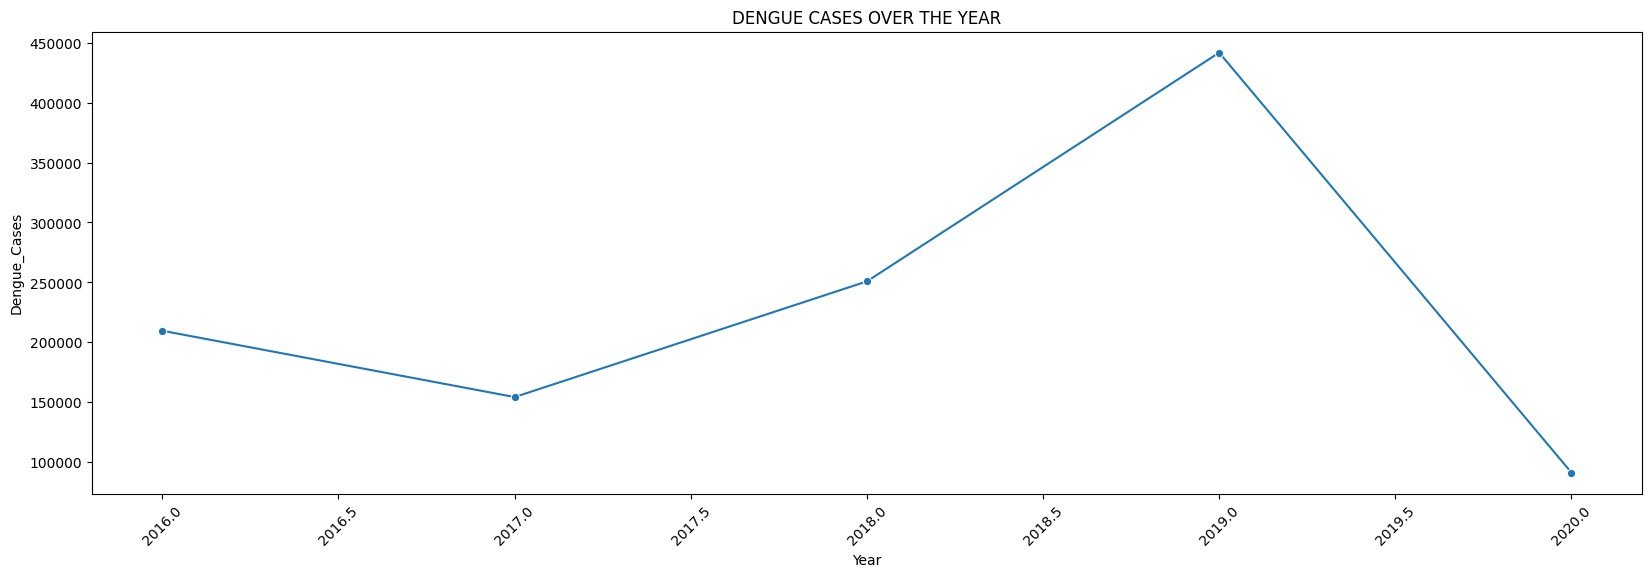

In [10]:
year_cases= dengue_f.groupby('Year')['Dengue_Cases'].sum().reset_index()
plt.figure(figsize=(20, 6))
sns.lineplot(data=year_cases, x='Year', y='Dengue_Cases', marker='o')
plt.title('DENGUE CASES OVER THE YEAR')
plt.xticks(rotation=45)

In [11]:
year_casess = dengue_f.groupby('Year')['Dengue_Cases'].sum()
highest_year_cases = year_casess.idxmax()
highest_year_cases_percent = year_casess.max()

In [12]:
print(f"{highest_year_cases}  {np.round(highest_year_cases_percent,1)}.")

2019  441902.


<h2>2019 has the highest cases in all years reaching 441902</h2>

<h1>3. What region has the most cases in the Philippines?</h1>

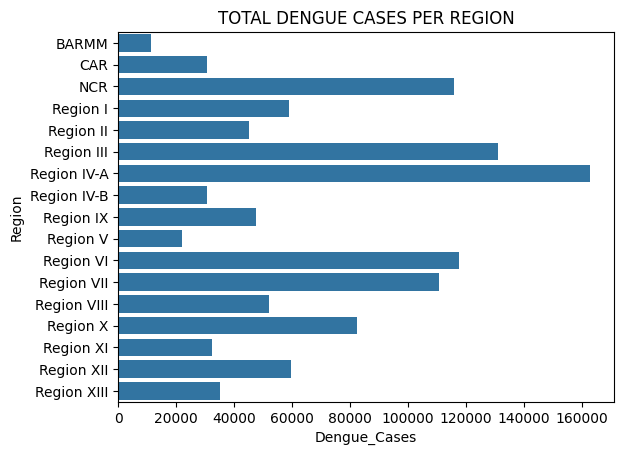

In [13]:
df_region = dengue_f.groupby("Region")["Dengue_Cases"].sum().reset_index()
sns.barplot(data=df_region, x="Dengue_Cases", y="Region")
plt.title("TOTAL DENGUE CASES PER REGION")
plt.show()

In [14]:
region_deaths = dengue_f.groupby('Region')['Dengue_Deaths'].sum()
region_deaths.sort_values(ascending=False).head()


Region
NCR           4008
Region XII    2796
Region VI     1825
Region VII    1760
CAR           1008
Name: Dengue_Deaths, dtype: int64

In [15]:
dengue_f.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=True).head()

Region
BARMM          11537
Region V       22167
CAR            30582
Region IV-B    30849
Region XI      32522
Name: Dengue_Cases, dtype: int64

In [16]:
region_cases = dengue_f.groupby('Region')['Dengue_Deaths'].sum()

region_with_most_cases = region_cases.idxmax()
highest_death_count = region_cases.max()

print("REGION WITH MOST DENGUE DEATHS:", region_with_most_cases)
print("TOTAL DENGUE DEATHS IN THAT REGION:", highest_death_count)

REGION WITH MOST DENGUE DEATHS: NCR
TOTAL DENGUE DEATHS IN THAT REGION: 4008


<h1>Cases in region 4A</h1>

In [17]:
Region_4A = dengue_f[dengue_f["Region"]=="Region IV-A"]
Region_4A

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Death_rate
180,January,2016,Region IV-A,2993,14,0.467758
181,February,2016,Region IV-A,2035,5,0.245700
182,March,2016,Region IV-A,1327,9,0.678222
183,April,2016,Region IV-A,838,1,0.119332
184,May,2016,Region IV-A,714,1,0.140056
185,June,2016,Region IV-A,778,4,0.514139
186,July,2016,Region IV-A,2270,6,0.264317
187,August,2016,Region IV-A,3218,2,0.062150
188,September,2016,Region IV-A,3454,28,0.810654
189,October,2016,Region IV-A,3175,20,0.629921


<h1>4. What month has the most highest cases in region 4A</h1>

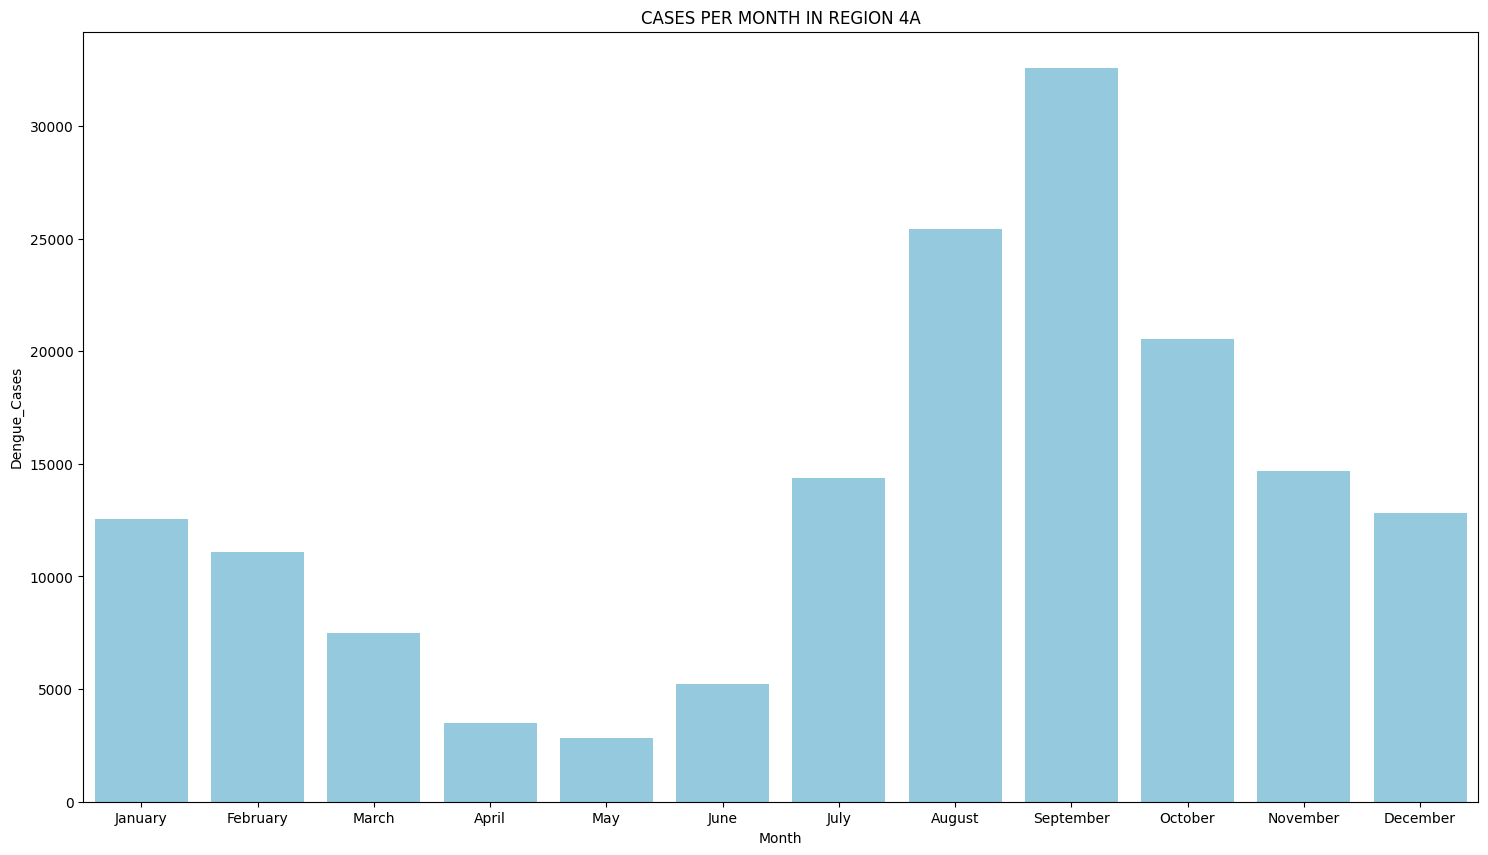

In [18]:
month_cases_4A= Region_4A.groupby('Month')['Dengue_Cases'].sum().reset_index()
sns.barplot(data=month_cases_4A, x='Month', y='Dengue_Cases',color='skyblue')
plt.title("CASES PER MONTH IN REGION 4A")
plt.gcf().set_size_inches(18,10)
plt.show()

In [19]:
month_cases_4A = Region_4A.groupby('Month')['Dengue_Cases'].sum()
highest_month_cases_4A = month_cases_4A.idxmax()
highest_month_cases_4A_percent = month_cases_4A.max()

In [20]:
print(f"{highest_month_cases_4A} has the highest cases in all months in Region 4A reaching {highest_month_cases_4A_percent}.")

September has the highest cases in all months in Region 4A reaching 32560.


<h1>5. What are the correlation between dengue cases and deaths</h1>

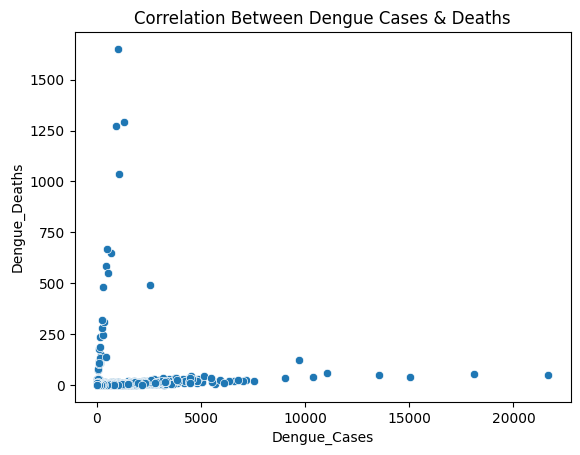

In [31]:
sns.scatterplot(data=dengue_f, x="Dengue_Cases", y="Dengue_Deaths")
plt.title("Correlation Between Dengue Cases & Deaths")
plt.show()


In [32]:
correlation_death_cases = dengue_f["Dengue_Cases"].corr(dengue_f["Dengue_Deaths"])
print("CORRELATION COEFFICIENT:", correlation_death_cases)

CORRELATION COEFFICIENT: 0.03832213720419488


<h1>6. Deaths in region 4A?</h1>

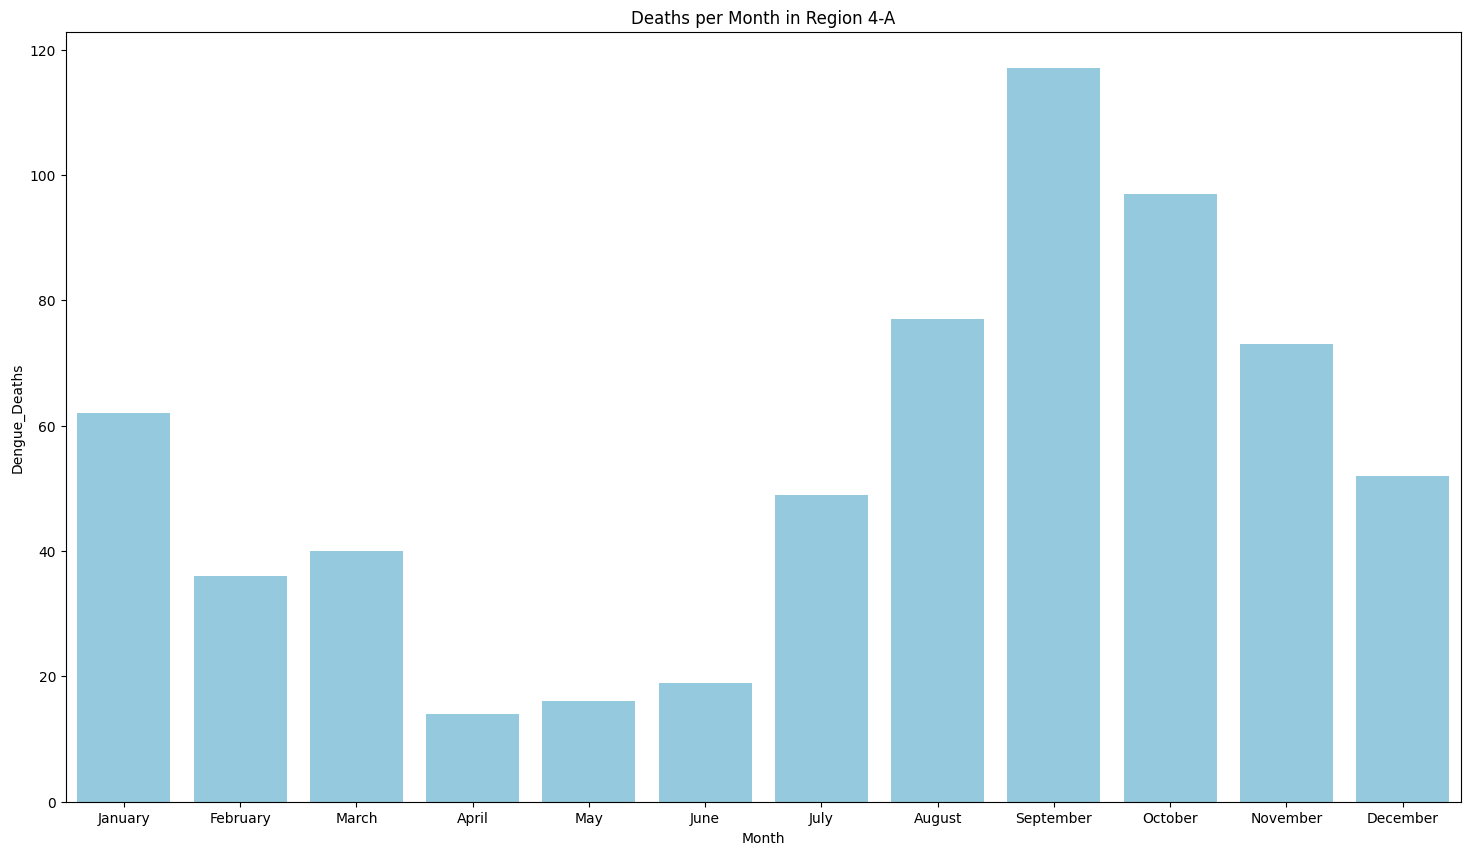

In [29]:
month_deaths_4A= Region_4A.groupby('Month')['Dengue_Deaths'].sum().reset_index()
sns.barplot(data=month_deaths_4A, x='Month', y='Dengue_Deaths',color='skyblue')
plt.title("Deaths per Month in Region 4-A")
plt.gcf().set_size_inches(18,10)
plt.show()

In [21]:
month_deaths_4A = Region_4A.groupby('Month')['Dengue_Deaths'].sum()
highest_month_deaths_4A = month_deaths_4A.idxmax()
highest_month_deaths_4A_percent = month_deaths_4A.max()

In [22]:
print(f"{highest_month_deaths_4A} has the highest deaths in all months in Region 4A reaching {highest_month_deaths_4A_percent}.")

September has the highest deaths in all months in Region 4A reaching 117.


<h1>7. Which Regions Had the Highest Fatality Rates from 2016 to 2020?</h1>


<h1>Fatality Rates Vary Across Philippine Regions</h1>

In [36]:
dengue_f["Fatality_Rate"] = (dengue_f["Dengue_Deaths"] / dengue_f["Dengue_Cases"]) * 100

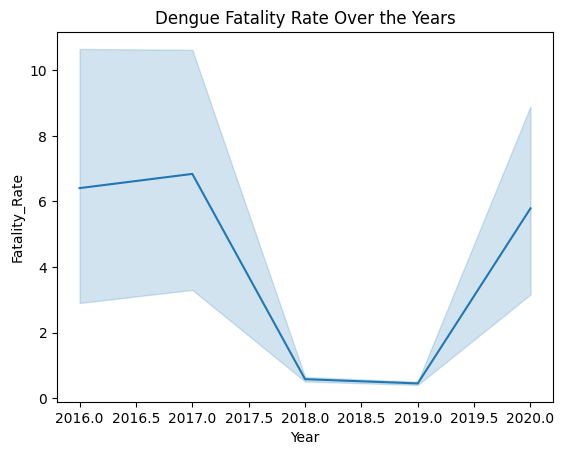

In [37]:
sns.lineplot(data=dengue_f, x="Year", y="Fatality_Rate")
plt.title("Dengue Fatality Rate Over the Years")
plt.show()

<h1> Dengue deaths from 2016-2020</h1>

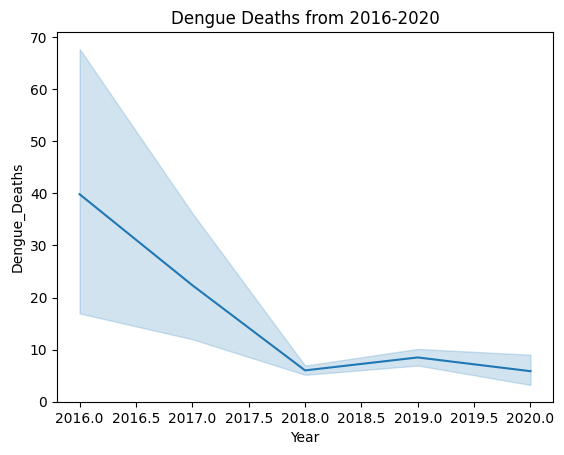

In [39]:
sns.lineplot(data=dengue_f, x="Year", y="Dengue_Deaths")
plt.title("Dengue Deaths from 2016-2020")
plt.show()

<h1>8. deathrate per region?</h1>

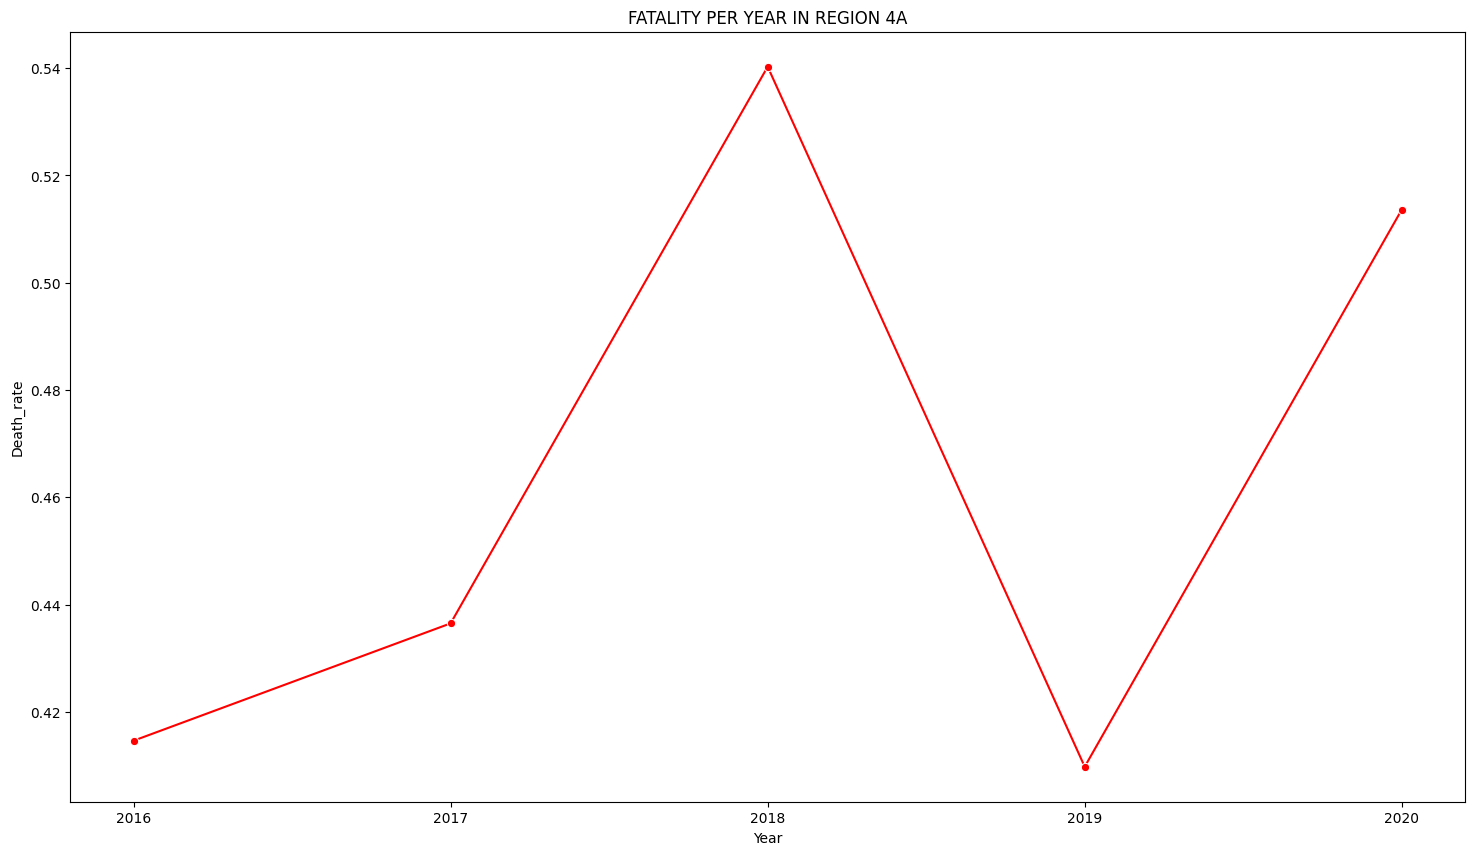

In [23]:
year_deathr_4A= Region_4A.groupby('Year')['Death_rate'].mean().reset_index()
sns.lineplot(data=year_deathr_4A, x='Year', y='Death_rate',color='red',marker="o")
plt.title("FATALITY PER YEAR IN REGION 4A")
plt.gcf().set_size_inches(18,10)
plt.xticks(ticks=year_deathr_4A['Year'], labels=year_deathr_4A['Year'].astype(int))
plt.show()

In [24]:
year_deathr_4A = Region_4A.groupby('Year')['Death_rate'].mean()
highest_year_mortality_4A = year_deathr_4A.idxmax()
highest_year_mortality_4A_percent = year_deathr_4A.max()

In [25]:
print(f"{highest_year_mortality_4A} has the highest death rate in all years in Region 4A reaching {np.round(highest_year_mortality_4A_percent,1)}%.")

2018 has the highest death rate in all years in Region 4A reaching 0.5%.


<h1>9. Dengue Mortality Rate?</h1>

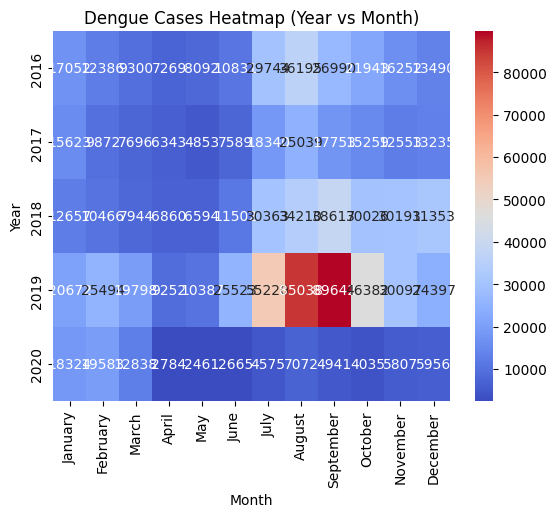

In [41]:
df_pivot = dengue_f.pivot_table(values="Dengue_Cases", index="Year", columns="Month", aggfunc="sum")
sns.heatmap(df_pivot, cmap="coolwarm", annot=True, fmt=".0f")
plt.title("Dengue Cases Heatmap (Year vs Month)")
plt.show()

In [42]:
(dengue_f['Dengue_Deaths'].sum() / dengue_f['Dengue_Cases'].sum()) * 100

np.float64(1.4679826568185286)

<h1>10. Death rate per region?</h1>

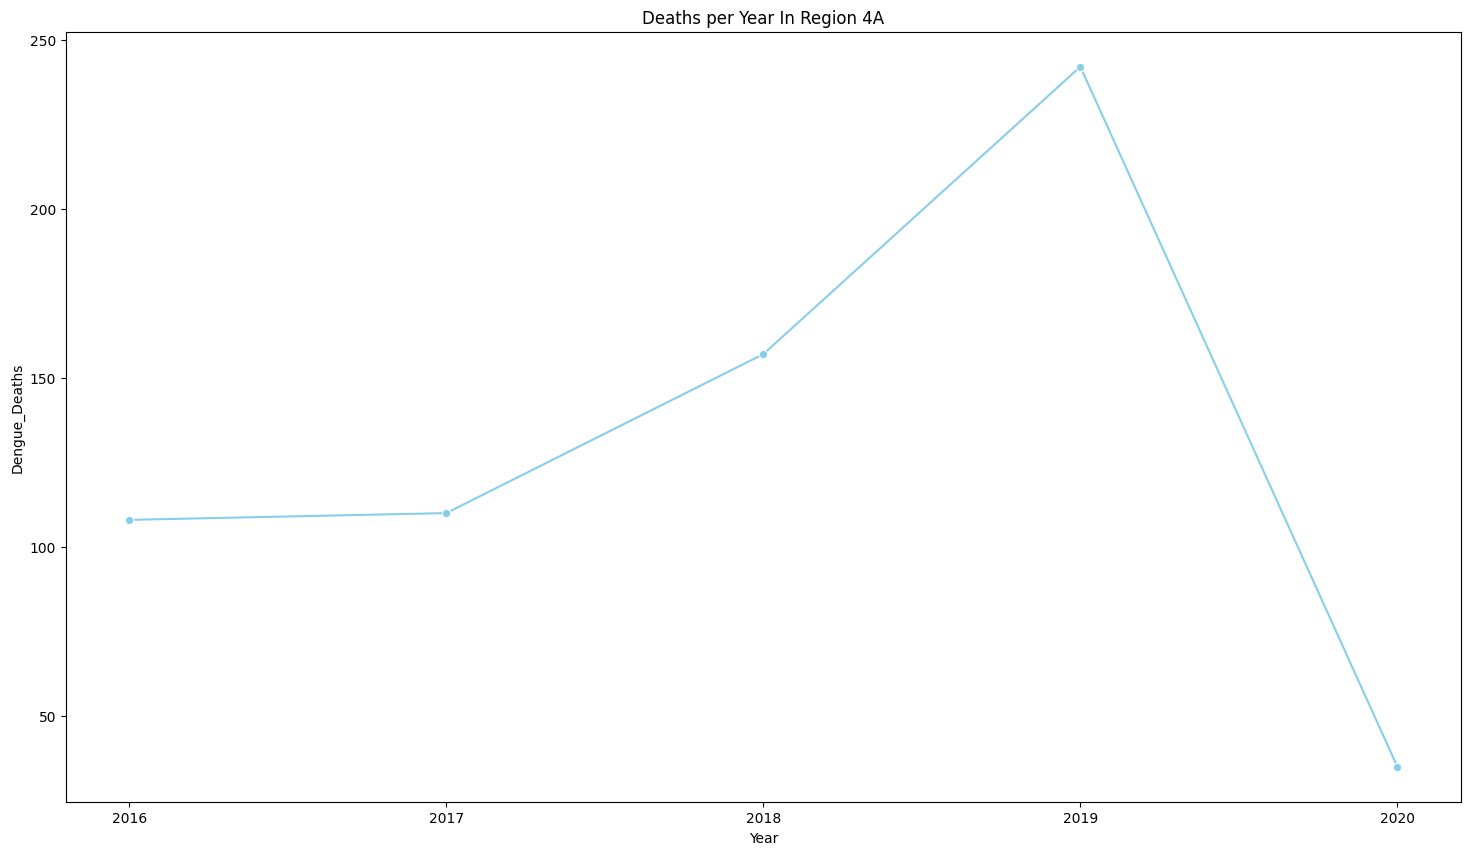

In [26]:
year_deaths_4A= Region_4A.groupby('Year')['Dengue_Deaths'].sum().reset_index()
sns.lineplot(data=year_deaths_4A, x='Year', y='Dengue_Deaths',color='skyblue',marker="o")
plt.title("Deaths per Year In Region 4A")
plt.xticks(ticks=year_deaths_4A['Year'], labels=year_deaths_4A['Year'].astype(int))
plt.gcf().set_size_inches(18,10)
plt.show()

In [27]:
year_deaths_4A = Region_4A.groupby('Year')['Dengue_Deaths'].sum()
highest_year_deaths_4A = year_deaths_4A.idxmax()
highest_year_deaths_4A_percent = year_deaths_4A.max()
year_deaths_4A.sum()

np.int64(652)

In [28]:
print(f"{highest_year_deaths_4A} has the highest cases in all years in Region 4A reaching {highest_year_deaths_4A_percent}. which is {np.round(242/652*100)}% of total cases.")

2019 has the highest cases in all years in Region 4A reaching 242. which is 37.0% of total cases.


<h1>11. Dengue Case Spread Across Regions</h1>

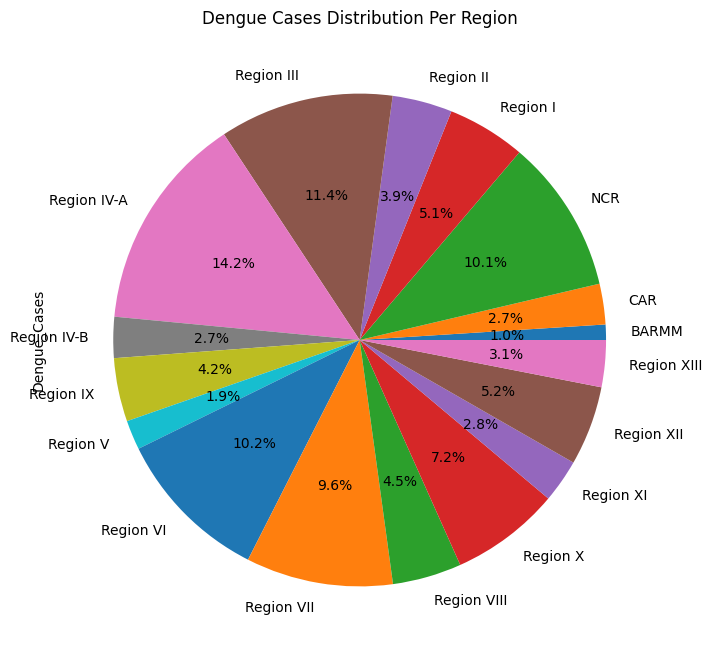

In [44]:
df_region = dengue_f.groupby("Region")["Dengue_Cases"].sum()
df_region.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8))
plt.title("Dengue Cases Distribution Per Region")
plt.show()

In [45]:
dengue_f.groupby('Month')['Dengue_Cases'].sum().sort_values().head()


Month
May         32387
April       32508
March       57576
June        58110
February    77801
Name: Dengue_Cases, dtype: int64

<h1>12. Mortality in Region 4-A</h1>

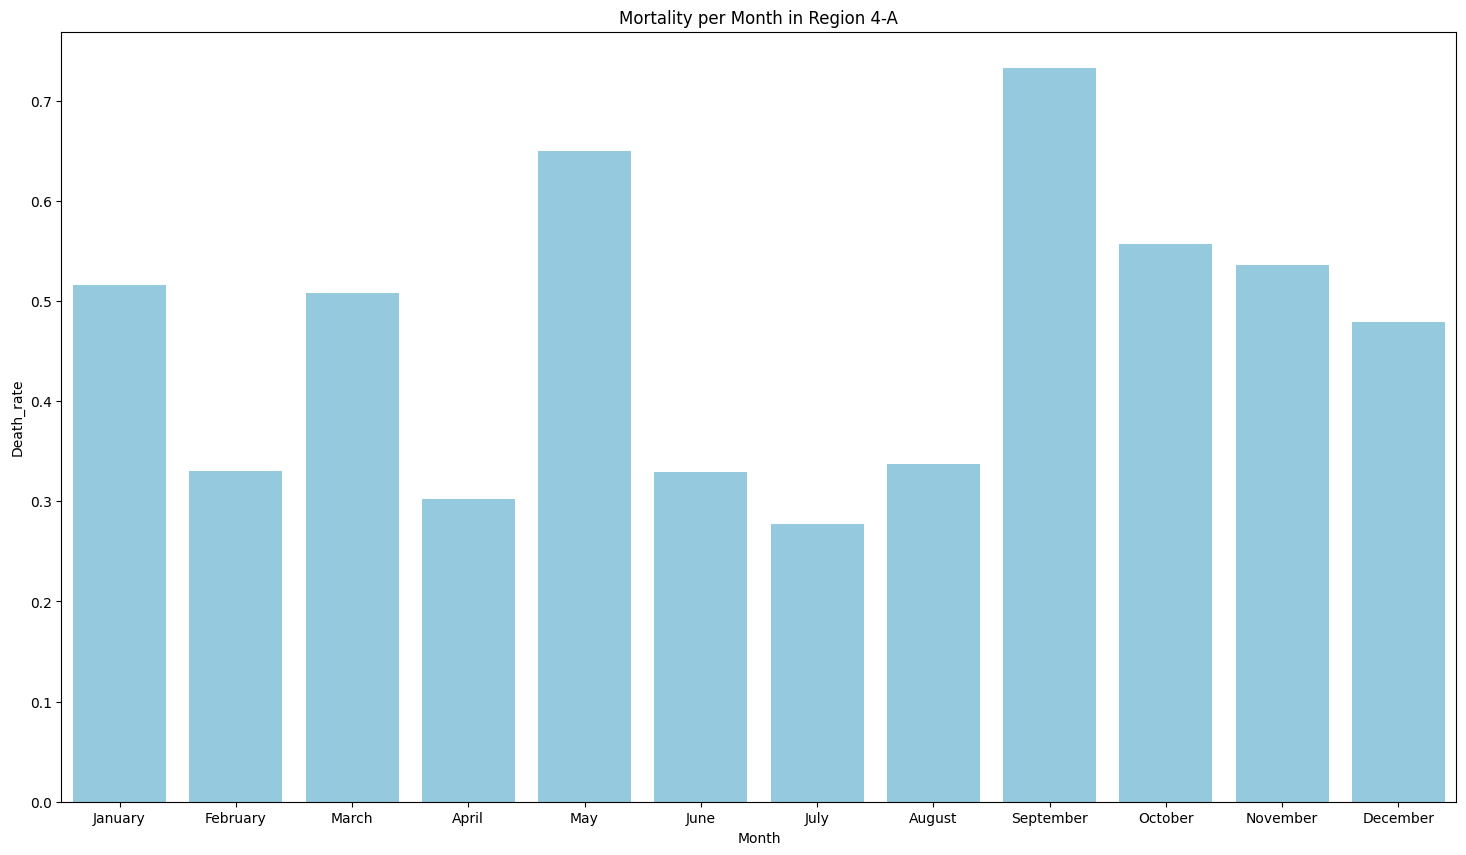

In [48]:
month_mortality_4A= Region_4A.groupby('Month')['Death_rate'].mean().reset_index()
sns.barplot(data=month_mortality_4A, x='Month', y='Death_rate',color='skyblue')
plt.title("Mortality per Month in Region 4-A")
plt.gcf().set_size_inches(18,10)
plt.show()

In [49]:
month_mortality_4A = Region_4A.groupby('Month')['Death_rate'].mean()
highest_mortality_4A = month_mortality_4A.idxmax()
highest_mortality_4A_percent = month_mortality_4A.max()

In [51]:
print(f"{highest_mortality_4A} Recorded the highest mortality rate across all months in Region 4-A, reaching {np.round(highest_mortality_4A_percent,2)}%.")

September Recorded the highest mortality rate across all months in Region 4-A, reaching 0.73%.


<h1>13. Dengue Deaths Peak During Months with High Case Counts</h1>

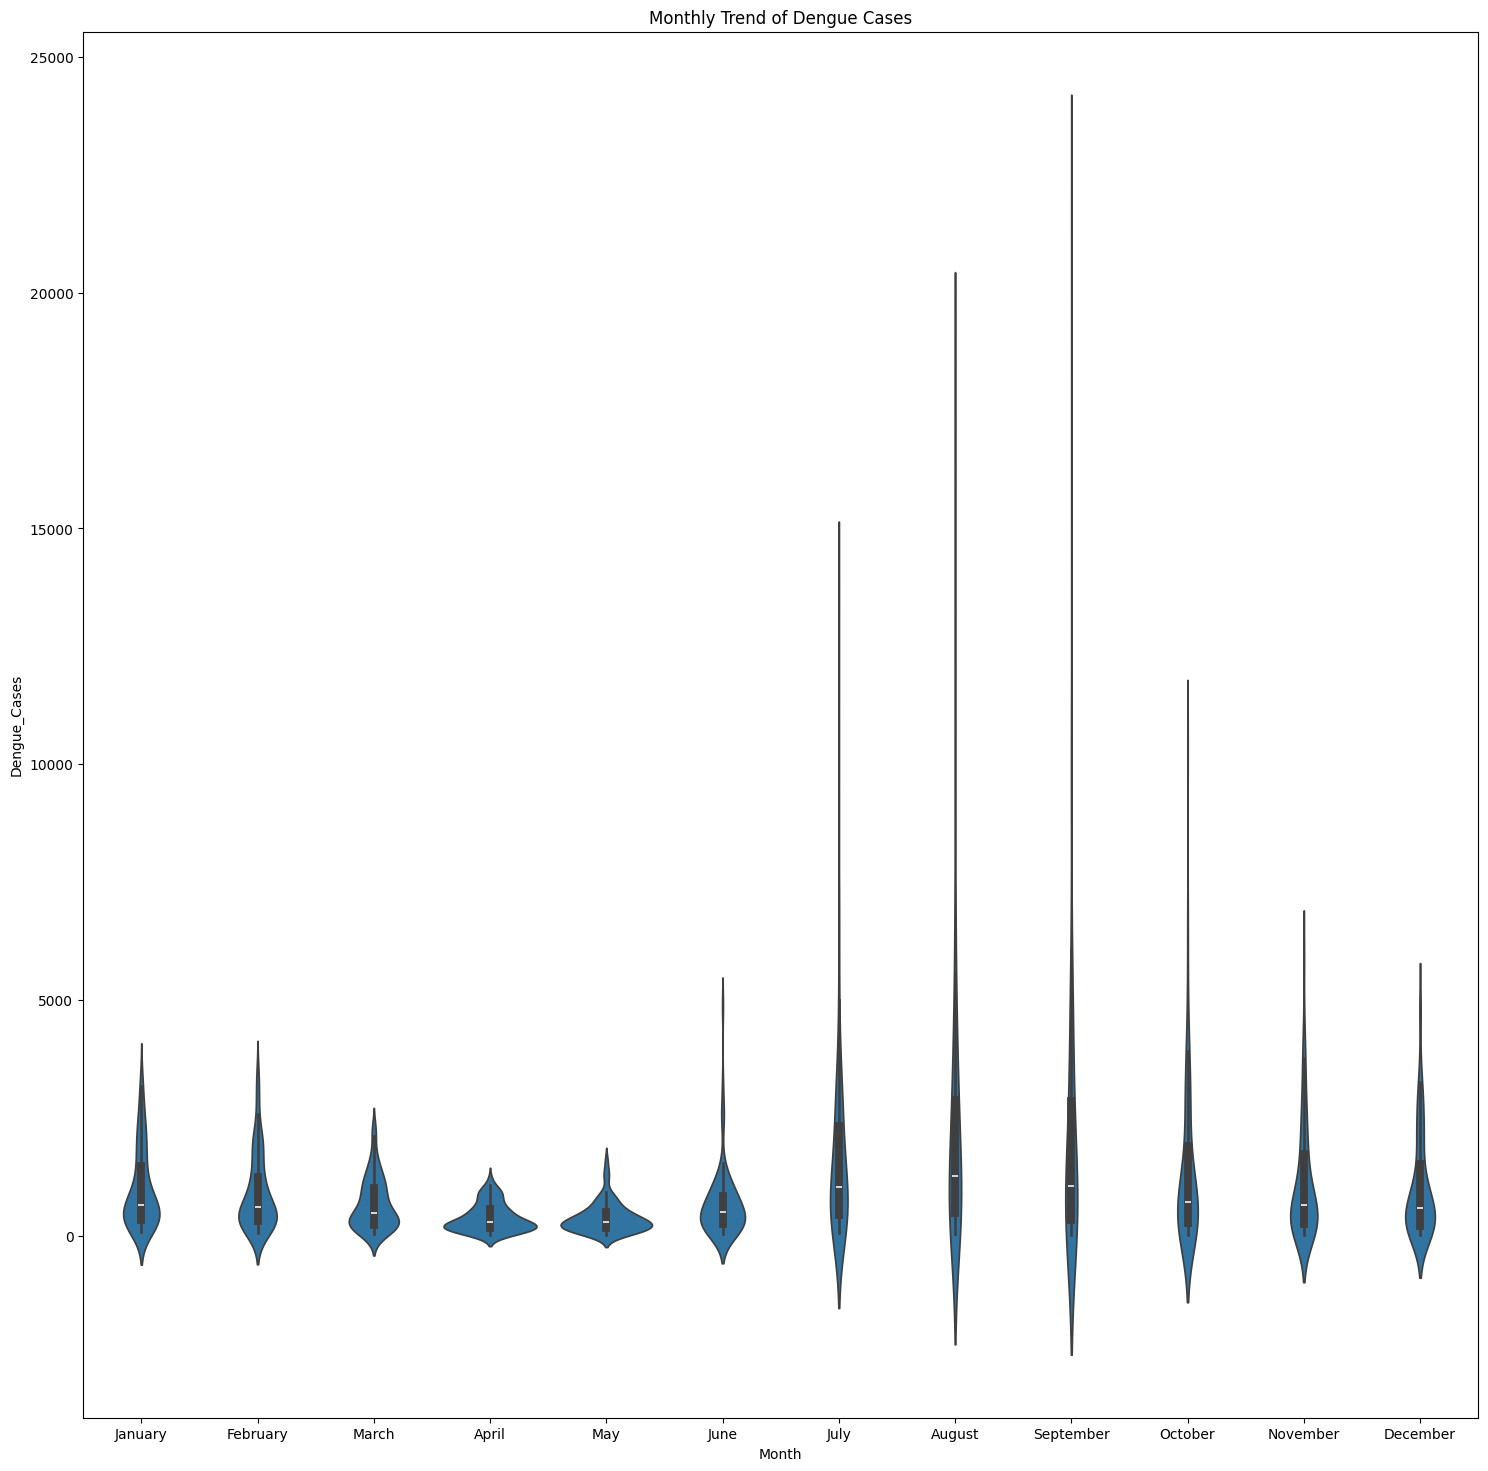

In [54]:
sns.violinplot(data=dengue_f, x="Month", y="Dengue_Cases")
plt.title("Monthly Trend of Dengue Cases")
plt.gcf().set_size_inches(18,18)
plt.show()

In [55]:
dengue_f.groupby('Month')['Dengue_Deaths'].sum().sort_values(ascending=False).head()


Month
October      6670
September    6148
August        714
November      613
July          611
Name: Dengue_Deaths, dtype: int64

<h1>14. Frequency in Region 4-A</h1>

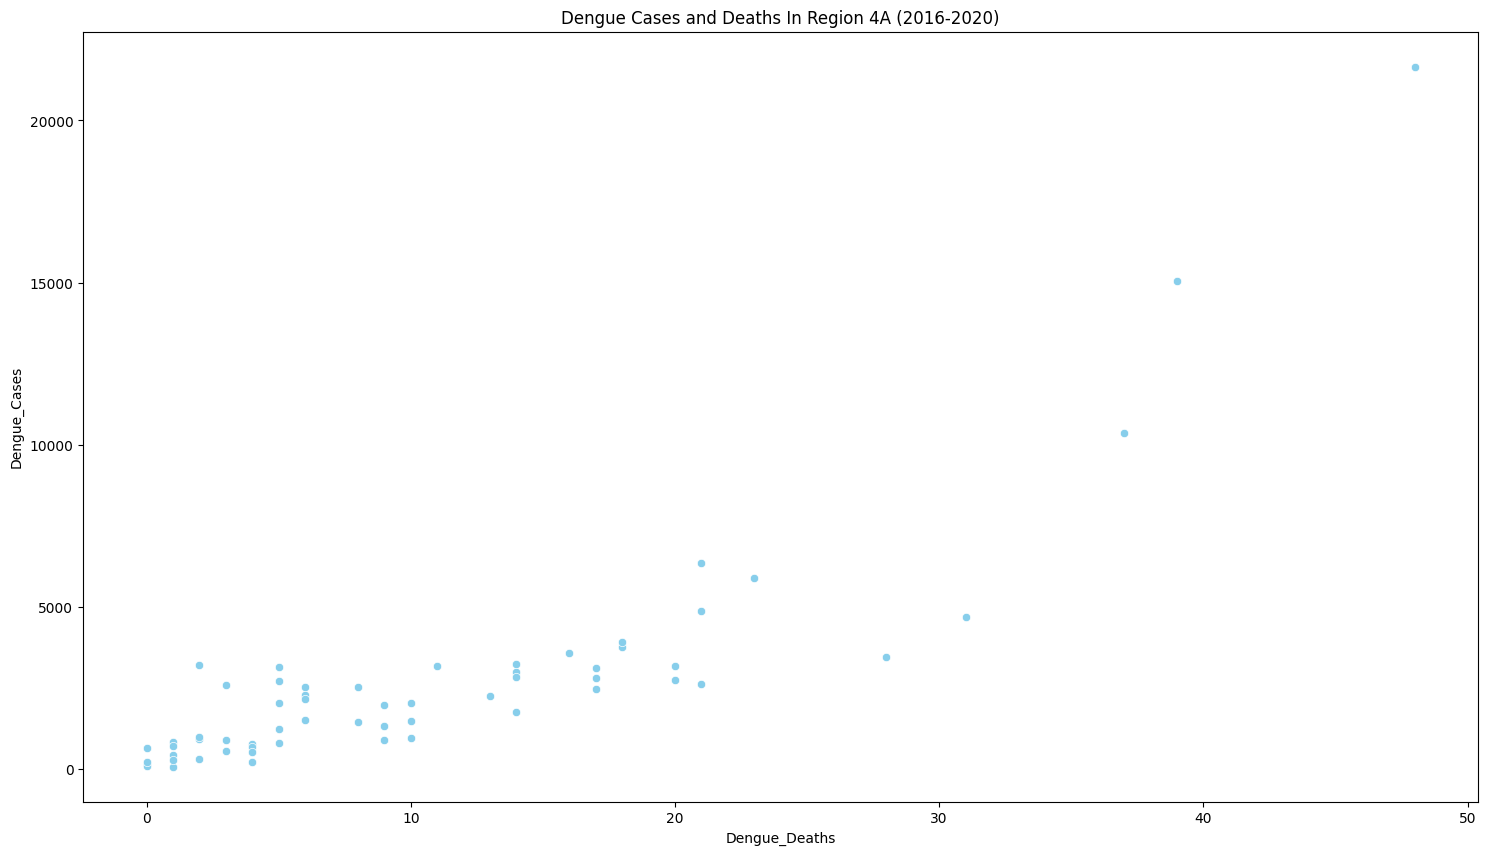

In [57]:
sns.scatterplot(data=Region_4A, x='Dengue_Deaths', y='Dengue_Cases',color='skyblue')
plt.title("Dengue Cases and Deaths In Region 4A (2016-2020)")
plt.gcf().set_size_inches(18,10)
plt.show()

In [60]:
total_cases_4A = Region_4A['Dengue_Cases'].sum()
total_deaths_4A = Region_4A['Dengue_Deaths'].sum()

print("TOTAL DENGUE CASES IN REGION 4-A (2016–2020):", total_cases_4A)
print("TOTAL DENGUE DEATHS IN REGION 4-A (2016–2020):", total_deaths_4A)



fatality_rate_4A = (total_deaths_4A / total_cases_4A) * 100
print("AVERAGE FATALITY RATE IN REGION 4-A (2016–2020):", round(fatality_rate_4A, 2), "%")

TOTAL DENGUE CASES IN REGION 4-A (2016–2020): 163029
TOTAL DENGUE DEATHS IN REGION 4-A (2016–2020): 652
AVERAGE FATALITY RATE IN REGION 4-A (2016–2020): 0.4 %


<h1>15. Top 5 Regions Most Affected by Dengue</h1>

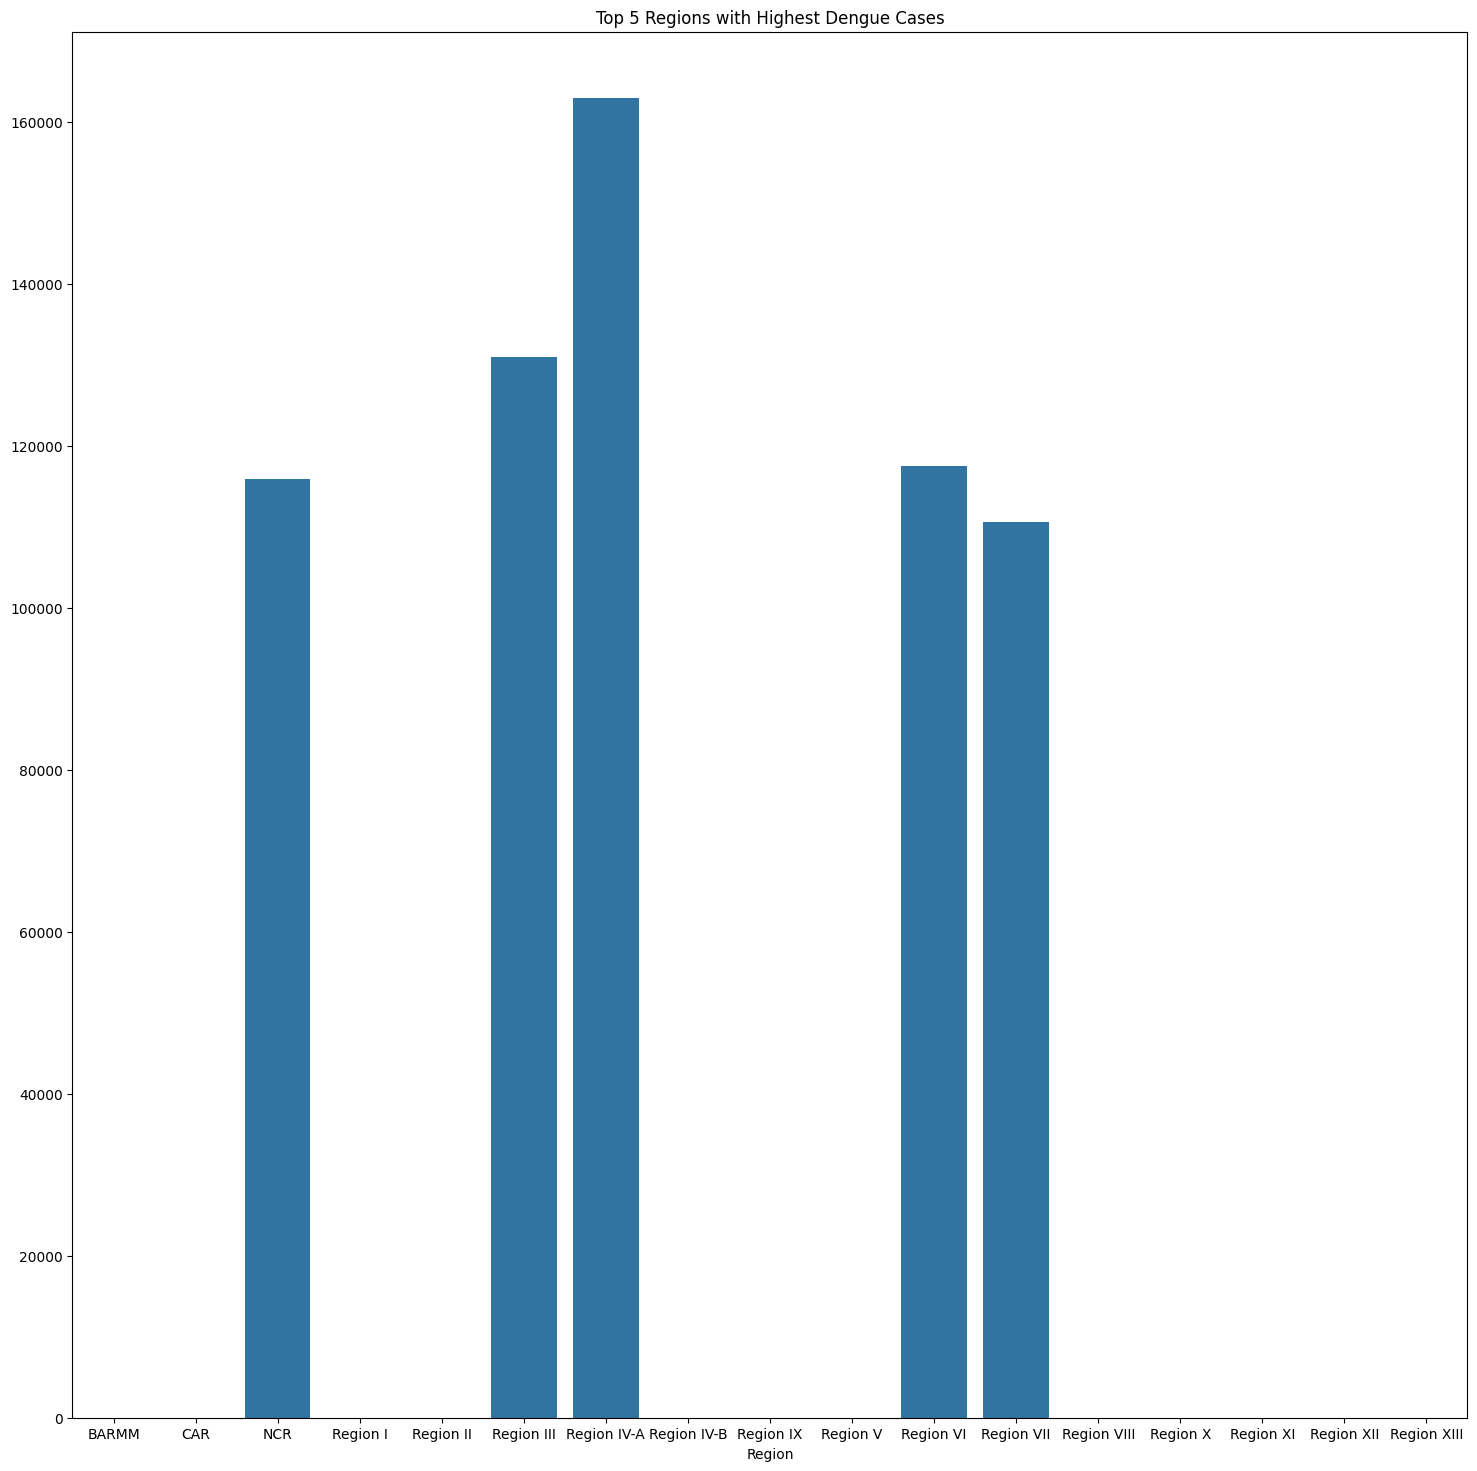

In [64]:
top_regions = dengue_f.groupby("Region")["Dengue_Cases"].sum().nlargest(5)
sns.barplot(x=top_regions.index, y=top_regions.values)
plt.title("Top 5 Regions with Highest Dengue Cases")
plt.gcf().set_size_inches(18,18)
plt.show()

In [65]:
top_regions = dengue_f.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False).head(5)

In [66]:
top_regions

Region
Region IV-A    163029
Region III     131064
Region VI      117523
NCR            115966
Region VII     110683
Name: Dengue_Cases, dtype: int64

<h1>16. Unusually Low Dengue Deaths Recorded in Some Years</h1>

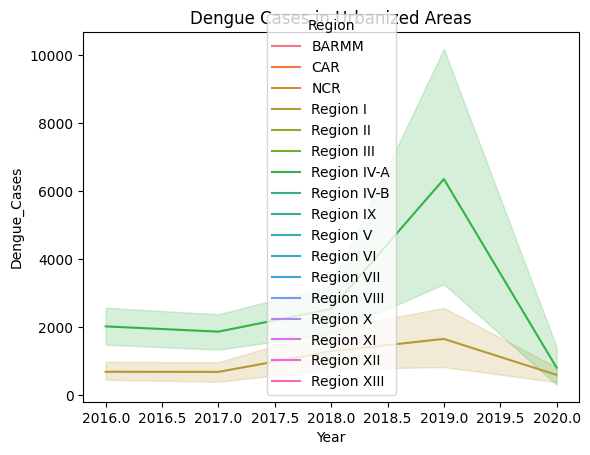

In [69]:
urban_regions = ['Region I', 'Region IV-A', 'Metro Manila']
df_urban = dengue_f[dengue_f['Region'].isin(urban_regions)]

sns.lineplot(data=df_urban, x="Year", y="Dengue_Cases", hue="Region")
plt.title("Dengue Cases in Urbanized Areas")
plt.show()

In [70]:
dengue_f.groupby('Year')['Dengue_Deaths'].sum().sort_values().head()


Year
2020    1195
2018    1226
2019    1733
2017    4563
2016    8127
Name: Dengue_Deaths, dtype: int64

<h1>17. Regions with Persistent Low Dengue Cases Might Be Benefiting from Stronger Prevention</h1>

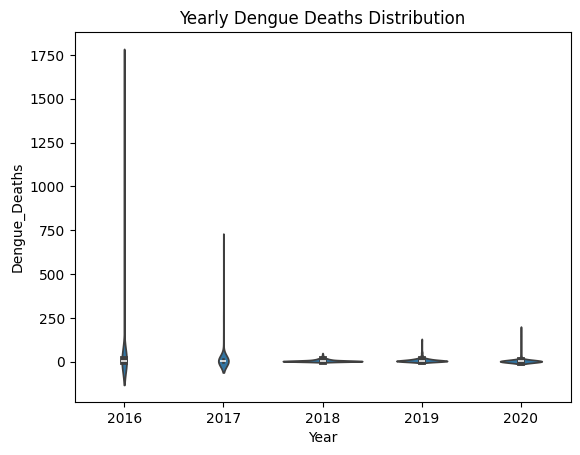

In [71]:
sns.violinplot(data=dengue_f, x="Year", y="Dengue_Deaths")
plt.title("Yearly Dengue Deaths Distribution")
plt.show()


In [72]:
dengue_f.groupby('Region')['Dengue_Cases'].sum().sort_values().head()


Region
BARMM          11537
Region V       22167
CAR            30582
Region IV-B    30849
Region XI      32522
Name: Dengue_Cases, dtype: int64

<h1>18. The Distribution of Dengue Cases Follows a Logarithmic Trend</h1>

<Axes: xlabel='Dengue_Cases', ylabel='Count'>

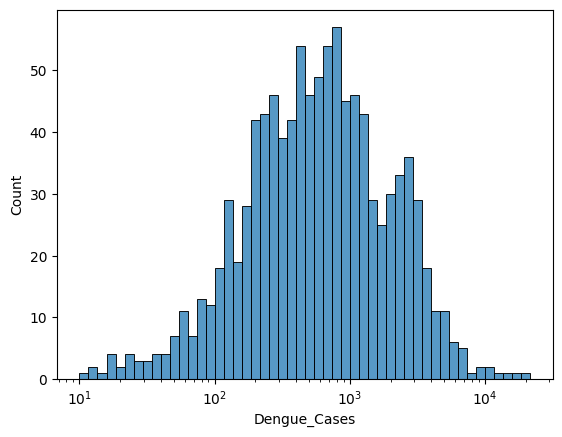

In [74]:
sns.histplot(dengue_f['Dengue_Cases'], bins=50, log_scale=True)

<h1>19. Urbanization Growth Might Be Linked to Dengue Case Increases</h1>

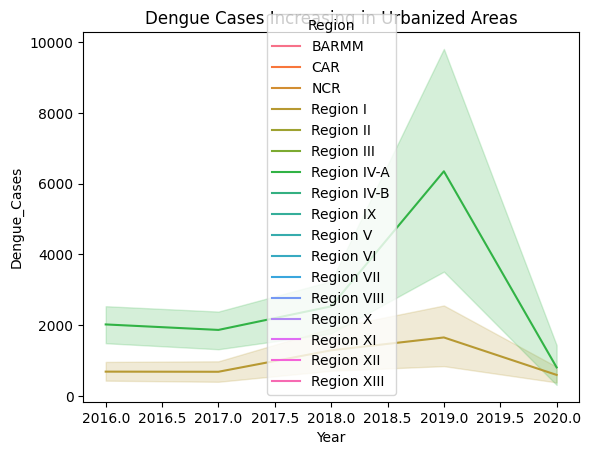

In [77]:
urban_regions = ['Region I', 'Region IV-A', 'Metro Manila']
df_urban = dengue_f[dengue_f['Region'].isin(urban_regions)]
sns.lineplot(data=df_urban, x='Year', y='Dengue_Cases', hue='Region')
plt.title('Dengue Cases Increasing in Urbanized Areas')
plt.show()

In [82]:
urban_regions = ['Region I', 'Region IV-A', 'Metro Manila']

df_urban = dengue_f[dengue_f['Region'].isin(urban_regions)]

In [83]:
df_urban

,Month,Year,Region,Dengue_Cases,Dengue_Deaths,Death_rate,Fatality_Rate
0,January,2016,Region I,705,1,0.141844,0.141844
1,February,2016,Region I,374,0,0.000000,0.000000
2,March,2016,Region I,276,0,0.000000,0.000000
3,April,2016,Region I,240,2,0.833333,0.833333
4,May,2016,Region I,243,1,0.411523,0.411523
...,...,...,...,...,...,...,...
235,August,2020,Region IV-A,291,1,0.343643,0.343643
236,September,2020,Region IV-A,231,4,1.731602,1.731602
237,October,2020,Region IV-A,325,2,0.615385,0.615385
238,November,2020,Region IV-A,542,3,0.553506,0.553506


<h1>20. Dengue Cases Exhibit Strong Seasonal Patterns</h1>

<Axes: xlabel='Year'>

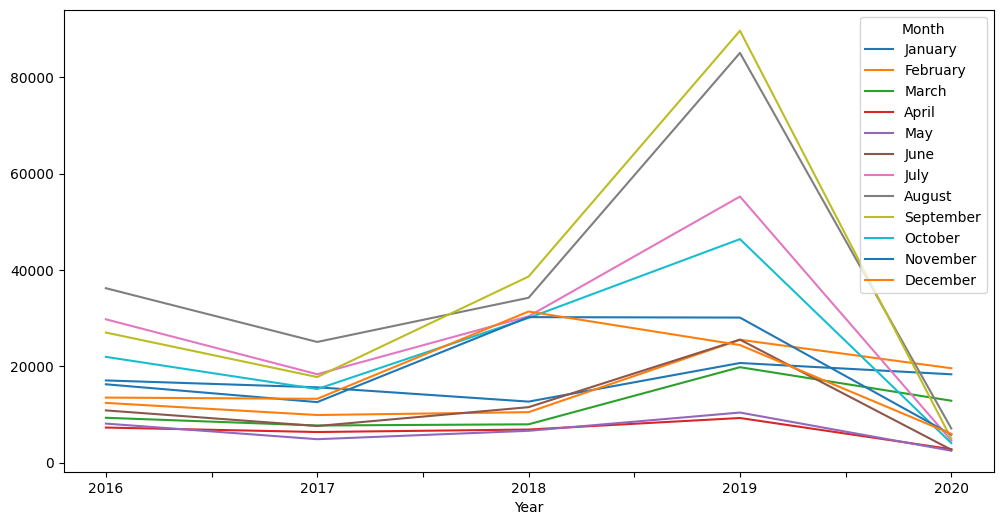

In [84]:
dengue_f.groupby(['Year', 'Month'])['Dengue_Cases'].sum().unstack().plot(kind='line', figsize=(12,6))